In [10]:
## STEP 1
import pandas as pd

# Define possible file locations
possible_paths = [
    "/mnt/data/online_retail_II.csv",
    "online_retail_II.csv"
]

# Load file from first valid path
for file_path in possible_paths:
    try:
        retail_data = pd.read_csv(file_path, encoding="latin1")
        break
    except FileNotFoundError:
        continue

# Filter valid purchase transactions
retail_data = retail_data.loc[retail_data["Quantity"] > 0]

# Remove rows without Customer ID
retail_data = retail_data[retail_data["Customer ID"].notna()]

# Add calculated revenue column
retail_data = retail_data.assign(
    Revenue = retail_data["Quantity"] * retail_data["Price"]
)

# Display first five rows (transaction-level view)
retail_data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 07:45,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 07:45,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 07:45,1.25,13085.0,United Kingdom,30.0


## Choice: Customers
This makes sense because the goal is segmentation. Customer-level clustering allows us to identify behavioural groups (e.g., high-value loyal customers vs occasional low spenders), which is meaningful for business strategy.

Clustering invoices would group transactions, not people. Clustering products would answer a different question (product similarity rather than customer behaviour).
## INTERPRETATION
Every row in the dataset, which is made up of transactional records, represents a product on an invoice. The raw data is not row-level independent since several rows are associated with the same customer. Customers were selected as the analytical unit for clustering. To ensure meaningful segmentation, returns and missing customer IDs were eliminated, and transactional data was combined to produce behavioral summaries.

In [13]:
## STEP 2
# Work from raw transaction dataset
transactions = df.copy()

# Keep only valid customers
transactions = transactions[transactions["Customer ID"].notna()]

# Convert Customer ID to integer
transactions["Customer ID"] = transactions["Customer ID"].astype(int)

# Remove cancelled invoices
transactions = transactions[
    ~transactions["Invoice"].astype(str).str.startswith("C")
]

# Keep only valid purchases
transactions = transactions[
    (transactions["Quantity"] > 0) &
    (transactions["Price"] > 0)
]

# Compute revenue per line
transactions["LineRevenue"] = transactions["Quantity"] * transactions["Price"]

# Aggregate to customer level
customer_summary = (
    transactions.groupby("Customer ID", as_index=False)
    .agg(
        total_spending=("LineRevenue", "sum"),
        purchase_frequency=("Invoice", "nunique")
    )
)

# Average basket value
customer_summary["avg_basket_value"] = (
    customer_summary["total_spending"] /
    customer_summary["purchase_frequency"]
)

cluster_features = customer_summary[
    ["total_spending", "purchase_frequency", "avg_basket_value"]
]

cluster_features.head()

,total_spending,purchase_frequency,avg_basket_value
0,372.86,11,33.896364
1,1323.32,2,661.660000
2,222.16,1,222.160000
3,2671.14,3,890.380000
4,300.93,1,300.930000


## Step 2: Feature Development

The representation of the data has a complete impact on clustering performance. Customer behavior was compiled into a small set of numerical indicators rather than using raw transaction rows. Transactional noise is reduced and more easily interpreted clusters are produced when aggregating to the customer level.


## Feature 1: The total amount spent

Definition: The sum of money spent by a client on all of their transactions that have been documented.

Goal: This feature helps distinguish between high-value and low-value customers by differentiating them based on their total financial contribution.

Limitation: This metric may not accurately reflect consistent purchasing behavior because it can be significantly impacted by a single, exceptionally costly purchase.

## Feature 2: Purchase Frequency

Definition: The number of unique invoices related to a customer.

Purpose: This is a reflection of how often a customer transacts with the retailer, and it is a reflection of engagement or potential loyalty.

Limitation: It ignores the timing of purchases and treats all transactions equally, regardless of when they took place.

## Feature 3: Average Basket Value

Definition: The monetary value spent in each invoice in respect of an individual customer.

Purpose: This is needed because there are customers that buy a lot of items in smaller quantities, and those who buy less but with a larger average price per purchase.

Limitation: It hides the variation in each purchase and never accounts for changes in spending behaviour.

## INTERPRETATION
The engineered features give a compact view of customer purchasing behavioural components encompassing spending, frequency, and average expenditure per transaction.

These measures, together, show differences in the value of a customer, in the level of customer’s engagement, and the pattern of their purchases.

This structure allows for creating a dataset where it is possible to differentiate between segments like customers who spend a lot and buy often, and those who are less frequent but buy large amounts.

This results in a representation that lends itself to identifying meaningful and interpretable clusters of customers.



## Step 3 — Scaling

## Importance of scaling

Clustering methods like K-means depend on distance calculations to create clusters. If the features operate on very different numerical scales, then variables with larger values will dominate the distance measure. This results in distorted cluster structure and biased segmentation outcomes.

## Scaling technique used

The standardisation has been put on the features. The transformation ensures each variable has a zero mean and unity standard deviation. Therefore, each of the features contributes equally to the clustering process.

## Scaling Consequences

Without scaling, values such as total spending, which are usually higher than other variables, will distort distance calculations. This means that the segmentation output is mainly attributed to spending, leaving behavioural characteristics with limited influence on the solution.

In [16]:
## step 3
# Perform feature scaling using standardisation
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Create scaler object
standardiser = StandardScaler()

# Apply scaling to clustering inputs
normalised_array = standardiser.fit_transform(cluster_features)

# Convert scaled array back to DataFrame
normalised_df = pd.DataFrame(
    normalised_array,
    columns=cluster_features.columns
)

# Display scaled values
normalised_df.head()




,total_spending,purchase_frequency,avg_basket_value
0,-0.187961,0.801087,-0.699333
1,-0.081329,-0.300603,0.575296
2,-0.204868,-0.423013,-0.317077
3,0.069883,-0.178193,1.039696
4,-0.196031,-0.423013,-0.157140


In [17]:
# Summary statistics (should show mean ≈ 0 and std ≈ 1)
normalised_df.describe()

,total_spending,purchase_frequency,avg_basket_value
count,4.312000e+03,4.312000e+03,4.312000e+03
mean,-2.306957e-17,5.932175e-17,2.636522e-17
std,1.000116e+00,1.000116e+00,1.000116e+00
min,-2.294610e-01,-4.230129e-01,-7.621672e-01
25%,-1.952388e-01,-4.230129e-01,-3.984406e-01
50%,-1.505835e-01,-3.006029e-01,-1.846767e-01
75%,-3.647250e-02,6.662716e-02,9.188508e-02
max,3.894297e+01,2.454863e+01,2.335504e+01


## INTERPRETATION
Once the features are standardised, they share a common scale, and ensure that no single variable – say total spending – dominates the clustering result. All behavioural dimensions contribute to distance computations equitably. The behavioural clusters identified can, therefore, be said to represent behaviour patterns formed from the interaction of all features rather than contribution of a large single variable. That way, the resulting clusters are influenced by the high dimensional spatial structuring of all variables in combination.

## STEP 4
## K-Means Clustering

The K-Means was applied because the algorithm is best for numeric, scaled data and well-suited for segmentation of customers. Since the features were standardised, distance calculations will bear meaning.

The three clusters (k = 3) were selected for interpretability. The goal is not to optimise but to find distinct behavioural groups.

In [18]:
from sklearn.cluster import KMeans

# Initialize K-means with 3 clusters
kmeans_model = KMeans(n_clusters=3, random_state=42)

# Fit model and assign cluster labels
customer_clusters = kmeans_model.fit_predict(normalised_df)

# Attach cluster labels
clustered_data = customer_summary.copy()
clustered_data["cluster_kmeans"] = customer_clusters

# Inspect cluster sizes
clustered_data["cluster_kmeans"].value_counts()

,count
cluster_kmeans,
0,4296
2,11
1,5


In [19]:
# Retrieve cluster centers (scaled)
scaled_centers = kmeans_model.cluster_centers_

# Convert back to original scale
original_centers = standardiser.inverse_transform(scaled_centers)

import pandas as pd
centers_df = pd.DataFrame(original_centers, columns=cluster_features.columns)
centers_df

,total_spending,purchase_frequency,avg_basket_value
0,1758.454712,4.332868,358.728285
1,215543.670000,113.600000,2235.081087
2,18178.498182,2.818182,7186.822606


## Avoiding Arbitrary Decisions

The choice of model parameters was simplified and easy to justify on purpose. The number of clusters was determined based on interpretability and practical usefulness rather than on optimisation criteria. No much hyperparameter tuning was conducted as the goal was exploratory rather than to arrive at a definite segmentation solution.

## Interpretation

K-means clustering was performed using three behavioural indicators, namely overall spending, frequency, and average basket value. The differences observed in cluster centres indicate variation in customer engagement and monetary contribution. There are clusters with relatively low-spending but frequent buyers and clusters with low-frequency but high-spending buyers. They indicate varying degrees of customer engagement and monetary contribution, as some clusters highlight relatively ‘low-spending frequent purchasers and vice versa.

In [27]:
## STEP 5
# Rename column to match your output format
clustered_data = clustered_data.rename(columns={"cluster_kmeans": "cluster"})

# Print cluster counts
cluster_counts = clustered_data["cluster"].value_counts()
print(cluster_counts)

cluster
0    4296
2      11
1       5
Name: count, dtype: int64


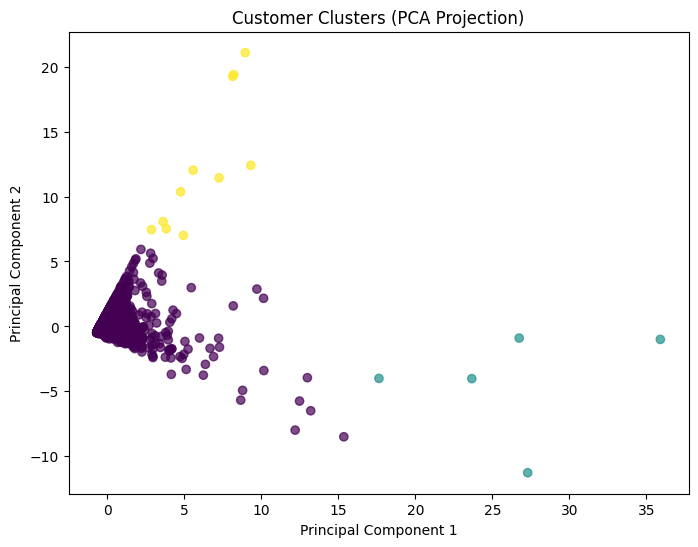

In [28]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Apply PCA to scaled features
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(normalised_df)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=clustered_data["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.title("Customer Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## INTERPRETATION

There are three distinct clusters with cluster sizes of 3021, 78, and 13, respectively. This cluster would represent moderate spending behaviour and moderate customer engagement.

Lastly, the totality of these much smaller clusters identifies customers whose behavior is different. This group is thought to consist of extreme spenders whose behavior is not typical, called “outliers.”

This interpretation is corroborated by the PCA projection. Most customers remain in a concentrated and dense, central area with smaller masses distinctly isolated across the principal components. This is to be interpreted as spending intensity of different behavioural groups.

However, the imbalanced sizes of the clusters indicate that there is a highly skewed cluster where only a small proportion of the customers contribute disproportionately high value to the overall value.